# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import math
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
print('Everything is imported boss')

Everything is imported boss


# **Data Exploration**

## **Load The data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [3]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 31300 Rows and 10 columns with 299 Duplicates


In [4]:
df.sample(10)

,tenure_months,monthly_charges,total_charges,num_services,support_calls,contract_type,payment_delays,data_usage_gb,num_complaints,churned
22078,38.0,107.75,4339.89,4.0,4.0,0.0,0.0,47.56,3.0,0
91,43.0,20.64,846.03,4.0,13.0,0.0,5.0,17.66,1.0,1
20230,71.0,119.94,7852.83,5.0,12.0,1.0,6.0,43.03,2.0,1
18257,24.0,33.45,774.00,1.0,14.0,2.0,7.0,14.92,0.0,1
2526,27.0,93.25,2575.23,7.0,11.0,0.0,6.0,9.67,3.0,1
24592,1.0,61.66,56.41,5.0,6.0,2.0,5.0,44.59,0.0,0
5616,28.0,54.92,1401.61,6.0,9.0,0.0,2.0,14.73,4.0,1
998,18.0,103.72,1705.14,6.0,4.0,0.0,6.0,1.74,4.0,1
23492,10.0,50.46,460.45,4.0,5.0,1.0,NaN,21.99,0.0,0
12613,15.0,74.13,1100.33,3.0,0.0,2.0,NaN,23.65,0.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31300 entries, 0 to 31299
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tenure_months    30672 non-null  float64
 1   monthly_charges  30676 non-null  str    
 2   total_charges    30674 non-null  float64
 3   num_services     30677 non-null  float64
 4   support_calls    30670 non-null  float64
 5   contract_type    30675 non-null  float64
 6   payment_delays   30674 non-null  float64
 7   data_usage_gb    30676 non-null  float64
 8   num_complaints   30670 non-null  float64
 9   churned          31300 non-null  int64  
dtypes: float64(8), int64(1), str(1)
memory usage: 2.5 MB


In [6]:
df.describe()

,tenure_months,total_charges,num_services,support_calls,contract_type,payment_delays,data_usage_gb,num_complaints,churned
count,30672.000000,30674.000000,30677.000000,30670.000000,30675.000000,30674.000000,30676.000000,30670.000000,31300.000000
mean,35.858275,2515.190046,3.998403,6.968503,1.013757,3.500782,25.011668,1.999935,0.501246
std,20.498827,1879.584600,2.003720,4.312659,0.816833,2.303303,14.424259,1.411190,0.500006
min,-8.000000,19.800000,1.000000,-3.000000,0.000000,0.000000,-10.000000,-2.000000,0.000000
25%,18.000000,999.247500,2.000000,3.000000,0.000000,1.000000,12.530000,1.000000,0.000000
50%,36.000000,2067.545000,4.000000,7.000000,1.000000,4.000000,25.040000,2.000000,1.000000
75%,53.000000,3696.197500,6.000000,11.000000,2.000000,6.000000,37.500000,3.000000,1.000000
max,71.000000,9211.390000,7.000000,14.000000,2.000000,7.000000,50.000000,4.000000,1.000000


In [7]:
df.isna().sum()

tenure_months      628
monthly_charges    624
total_charges      626
num_services       623
support_calls      630
contract_type      625
payment_delays     626
data_usage_gb      624
num_complaints     630
churned              0
dtype: int64

# **Data Cleaning**

## **create Copy**

In [8]:
df_copy = df.copy()
print('copy created')

copy created


## **DataType**

In [9]:
df_copy['monthly_charges'] = df_copy['monthly_charges'].replace('_err','',regex=True).astype('float')

## **Impossoble Values**

In [10]:
Columns = df_copy.columns.tolist()

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [11]:
Columns = df_copy.columns.tolist()
Columns.remove('contract_type')
Columns.remove('churned')
Columns.remove('num_complaints')

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [12]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 300
After: 0


In [13]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('tenure_months')
Round.remove('num_services')
Round.remove('support_calls')
Round.remove('contract_type')
Round.remove('payment_delays')
Round.remove('num_complaints')
Round.remove('churned')

for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
Floor = ['tenure_months','num_services','support_calls','contract_type','payment_delays','num_complaints']
for col in Floor:
    df_copy[col] = df_copy[col].fillna(math.floor(df_copy[col].median()))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
tenure_months      622
monthly_charges    622
total_charges      855
num_services       620
support_calls      621
contract_type      620
payment_delays     620
data_usage_gb      621
num_complaints     621
churned              0
dtype: int64
NaN values in the Dataset After Cleaning is: 
tenure_months      0
monthly_charges    0
total_charges      0
num_services       0
support_calls      0
contract_type      0
payment_delays     0
data_usage_gb      0
num_complaints     0
churned            0
dtype: int64


# **Data Preperation**

In [14]:
features = df_copy.columns.tolist()
features.remove('churned')
X = df_copy[features]
y = df_copy['churned']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (31000, 9)
y Shape: (31000,)


In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (24800, 9)
X_test Shape:  (6200, 9)
y_train Shape: (24800,)
y_test Shape:  (6200,)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# **Model**

## **Train**

In [27]:
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

print(f"Best trees used: {model.best_iteration}")
print(f"Model trained ✅")

Best trees used: 122
Model trained ✅


## **Feature Importance**

In [28]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82      3115
         1.0       0.82      0.82      0.82      3085

    accuracy                           0.82      6200
   macro avg       0.82      0.82      0.82      6200
weighted avg       0.82      0.82      0.82      6200

Accuracy: 0.8210


## **Feature Importance**

In [29]:
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    imp = model.get_booster().get_score(importance_type=imp_type)
    print(f"\n{imp_type.upper()}:")
    for feat, score in sorted(imp.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feat:25} → {score:.4f}")


WEIGHT:
  f1                        → 726.0000
  f7                        → 669.0000
  f0                        → 645.0000
  f4                        → 472.0000
  f2                        → 461.0000
  f6                        → 397.0000
  f3                        → 332.0000
  f8                        → 307.0000
  f5                        → 240.0000

GAIN:
  f4                        → 40.8984
  f6                        → 38.2195
  f8                        → 36.0814
  f0                        → 22.1373
  f5                        → 16.3835
  f3                        → 12.7941
  f1                        → 8.0008
  f2                        → 5.6193
  f7                        → 4.9669

COVER:
  f8                        → 865.0931
  f6                        → 790.8074
  f4                        → 736.1680
  f5                        → 635.4361
  f3                        → 518.6319
  f0                        → 498.9263
  f2                        → 351.0981
  f1         

## **Overfitiing**

In [30]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")
print(f"Best iteration:    {model.best_iteration}")

Training Accuracy: 0.8485
Testing Accuracy:  0.8210
Gap:               0.0276
Best iteration:    122


## **Charts**

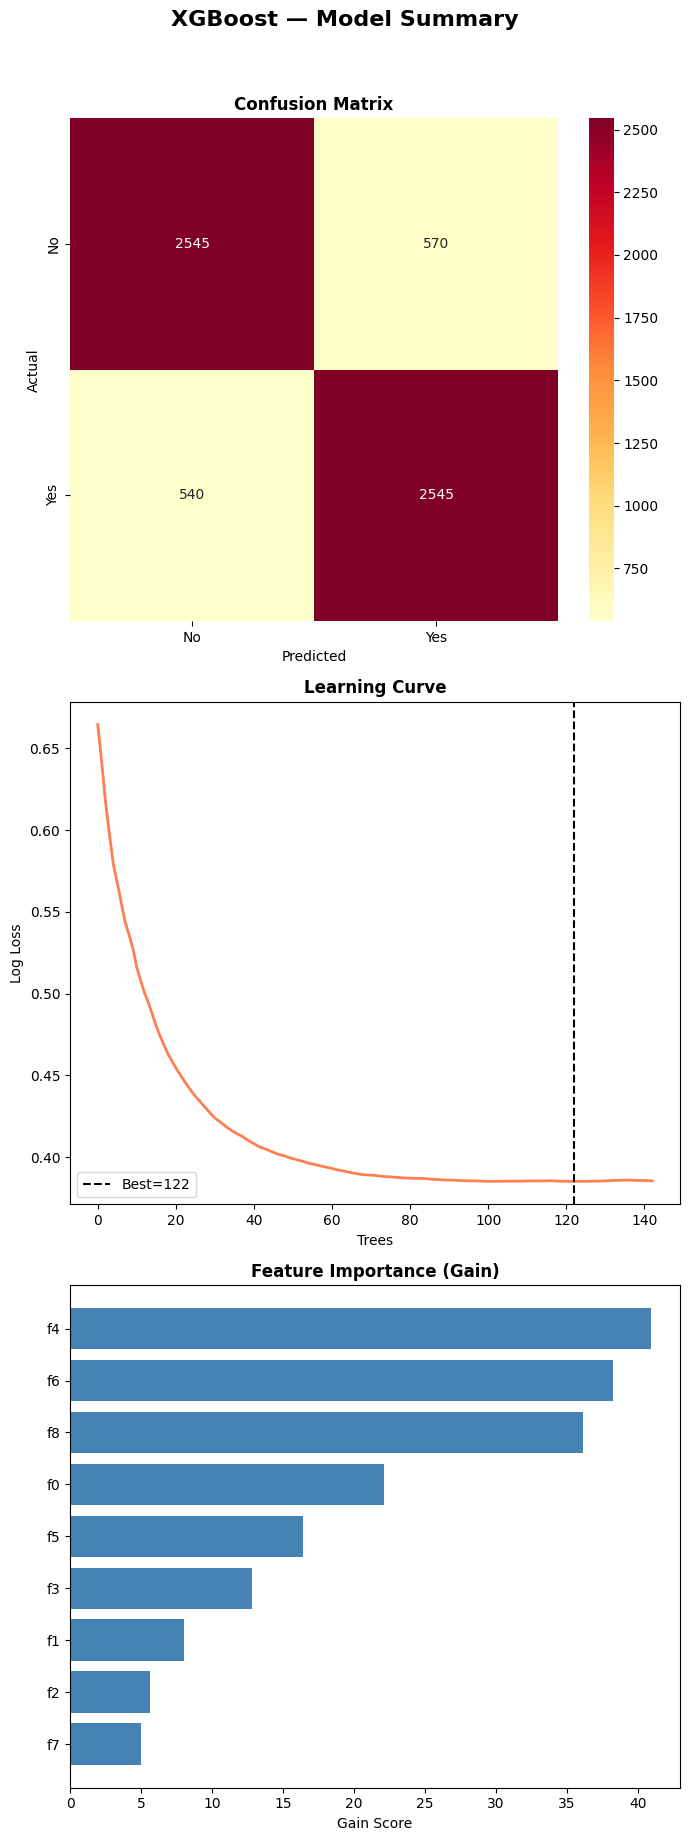

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(7, 18))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — Learning Curve
results = model.evals_result()
axes[1].plot(results['validation_0']['logloss'],
             color='coral', linewidth=2)
axes[1].axvline(model.best_iteration, linestyle='--',
                color='black', label=f'Best={model.best_iteration}')
axes[1].set_title('Learning Curve', fontweight='bold')
axes[1].set_xlabel('Trees')
axes[1].set_ylabel('Log Loss')
axes[1].legend()

# Plot 3 — Feature Importance (Gain)
imp_df = pd.DataFrame(
    model.get_booster().get_score(importance_type='gain').items(),
    columns=['Feature', 'Gain']
).sort_values('Gain')
axes[2].barh(imp_df['Feature'], imp_df['Gain'], color='steelblue')
axes[2].set_title('Feature Importance (Gain)', fontweight='bold')
axes[2].set_xlabel('Gain Score')

plt.suptitle('XGBoost — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()